# Reconstrucción de trayectorias con DBSCAN (Aprendizaje No Supervisado)
Cargando todas las librerías que se emplearán.

In [1]:
!pip install git+https://github.com/LAL/trackml-library.git
import numpy as np 
import pandas as pd 
import zipfile # Descomprimir archivos .zip
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from trackml.score import score_event
# import os  # Solo lo usé para obtener las rutas hazta los archivos .zip
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import (confusion_matrix,classification_report,ConfusionMatrixDisplay)
from sklearn.metrics import roc_curve, auc

  Cloning https://github.com/LAL/trackml-library.git to /tmp/pip-req-build-2c0s1lfv
  Running command git clone --filter=blob:none --quiet https://github.com/LAL/trackml-library.git /tmp/pip-req-build-2c0s1lfv
  Resolved https://github.com/LAL/trackml-library.git to commit 53a165e15a2c885f54c2bef1bd1ed53db6ed9648
  Preparing metadata (setup.py) ... done


In [2]:
'''
# Obtenemos las rutas a todos los archivos del reto
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
'''

# Nos quedamos con la ruta hacia el paquete de entrenamiento
# Nos quedaremos con los datos para un solo evento
ruta_train1 = '/kaggle/input/competitions/trackml-particle-identification/train_1.zip'
ruta_detectors = '/kaggle/input/competitions/trackml-particle-identification/detectors.zip'

# Abrimos el archivo .zip en modo lectura
zipi = zipfile.ZipFile(ruta_train1, 'r')

# Elegimos que evento queremos tratar
evento = 'event000001001'
# print(f"Cargando archivos para el prefijo: {evento}")


# Leemos cada archivo .csv correspondiente a ese evento
hits = pd.read_csv(zipi.open(f'train_1/{evento}-hits.csv'))
cells = pd.read_csv(zipi.open(f'train_1/{evento}-cells.csv'))
particles = pd.read_csv(zipi.open(f'train_1/{evento}-particles.csv'))
truth = pd.read_csv(zipi.open(f'train_1/{evento}-truth.csv'))

# Cerramos el archivo .zip
zipi.close()

# Abrimos el de detectores y obtenemos sus datos
zd = zipfile.ZipFile(ruta_detectors, "r")
detectors = pd.read_csv(zd.open("detectors.csv"))
zd.close()

In [3]:
# Definimos una función para ver que partículas son cercanas y etiquetarlas en un grupo.
def etiqueta_grupos(hits, eps=0.015):
    '''
    Primero extraemos las coordenadas espaciales donde ocurrió el impacto del archivo de hits.
    Como lo que tenemos es un detector cilindrico, lo mejor es trabajar en coordenadas cilíndricas.
    Definimos el radio, el ángulo y una magnitud llamada z_rel. Esta es porque como tenemos una 
    especie de hélice cónica, el avance en el eje z entre el radio de la helice es una magnitud constante.
    '''
    
    # Obtenemos las coordenadas y obtenemos el radio y el ángulo correspondiente
    x = hits['x']
    y = hits['y']
    z = hits['z']
    r = np.sqrt(x**2+y**2)
    phi = np.arctan2(y,x) 
    theta = np.arctan2(r,z)
    z_rel = z/(r+10**(-6))
    eta = -np.log(np.tan(theta/2))
    # Agrupamos las variables en coordenadas cilindricas en un array y las normalizaremos
    X = np.column_stack([np.cos(phi), np.sin(phi) ,z_rel, eta])
    # X = np.column_stack([theta,z_rel])
    X_scaled = StandardScaler().fit_transform(X)

    # Creamos los clusters, es decir, los grupos de partículas vecinas
    # Tomamos el algoritmo DBSCAN para saber cuantas partículas hay dentro de la esfera de radio eps
    # Exigimos que a partir de una particula en el interior de ese radio sea ya un cluster (min_sample = 1)
    # El algoritmo de optimización usado será el 'kd_tree'
    clusters = DBSCAN(eps=eps, min_samples=1, algorithm='kd_tree')
    etiquetas = clusters.fit_predict(X_scaled) # Nos devuelve las etiquetas del grupo al que pertenece cada partícula
    return etiquetas # Hay etiquetas con -1, significa que son ruido. No pertenecen a ningún grupo. Las eliminaré después.
 
# Añado a mi hits.cvs una columna extra con estas etiquetas
hits['etiqueta_grupo'] = etiqueta_grupos(hits)


In [7]:
'''
Para hacer una comparativa entre las etiquetas de grupo dadas por el DBSCAN y el archivo de truth.csv
añadimos otra columna al hits.csv que sea el 'particle_id' del archivo truth.csv
'''

comparativa = hits[['hit_id', 'etiqueta_grupo']].merge(truth[['hit_id', 'particle_id']], on='hit_id')
# print(comparativa.head(50))

# Eliminamos el ruido
comparativa_sin_ruido = comparativa[comparativa['etiqueta_grupo']!=-1]

# Ahora tengo que saber si las particulas de un mismo grupo son la misma o diferentes
# Uso .groupby para ver cuantas partículas diferentes hay en cada grupo y .nunique para saber si son únicas
particulas_por_grupo = comparativa_sin_ruido.groupby('etiqueta_grupo')['particle_id'].nunique()

# El total de grupos (de trayectorias) será:
total_grupos = len(particulas_por_grupo)
print(f"Total de trayectorias encontradas: {total_grupos}")

# El número de grupos con una sola partícula en ellos, es decir, un seguimiento perfecto de la trayectoria será:
tracks_perfectos = (particulas_por_grupo == 1).sum() # Sumamos todas las veces que en un grupo hay una sola partícula
print(f"Trayectorias perfectas de 1 sola partícula: {tracks_perfectos}")

Total de trayectorias encontradas: 29319
Trayectorias perfectas de 1 sola partícula: 17982


In [5]:
# Creo una función para crear el conjunto que usaremos para realizar obtener el score.
# Se necesita un Data Frame de 3 columnas, el identificador del evento, el identificador del hit y el identificador de la trayectoria.
def fun_submission(hits, labels, event_id=0):
    sub_data = np.column_stack(([event_id]*len(hits), hits.hit_id.values, labels))
    submission = pd.DataFrame(data=sub_data, columns=["event_id", "hit_id", "track_id"]).astype(int)
    return submission

Mejor eps   = 0.017
Mejor score = 18.98%


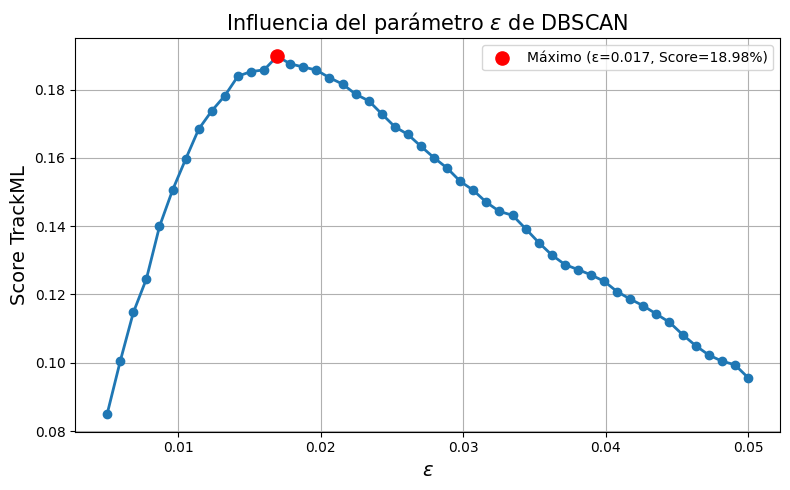

In [6]:
# Representación en función del eps
epss = np.linspace(0.005, 0.05, 50)
scores = []
for eps in epss:
    grupos = etiqueta_grupos(hits, eps)
    submission = fun_submission(hits, grupos)
    score = score_event(truth, submission[['hit_id', 'track_id']])
    scores.append(score)

idx_max = np.argmax(scores) # máximo de los scores
eps_opt = epss[idx_max]
score_max = scores[idx_max]

print(f"Mejor eps   = {eps_opt:.3f}")
print(f"Mejor score = {score_max*100:.2f}%")



plt.figure(figsize=(8,5))
plt.plot(epss,scores,"-o",linewidth=2,markersize=6)

plt.xlabel(r"$\varepsilon$", fontsize=14)
plt.ylabel("Score TrackML", fontsize=14)
plt.title("Influencia del parámetro $\\varepsilon$ de DBSCAN", fontsize=15)
plt.grid()
plt.tight_layout()
plt.scatter(eps_opt,score_max,color="red",s=90,zorder=3,label=f"Máximo (ε={eps_opt:.3f}, Score={score_max*100:.2f}%)")
plt.legend()
plt.savefig("score_vs_eps.png", dpi=600)
plt.savefig("score_vs_eps.pdf")

plt.show()


# Reconstrucción con aprendizaje supervisado (DNN)
Aqui comienza la segunda parte del codigo que consiste en el entrenamiento de una red densa con la capa de entrada, la de salida y 4 capas ocultas. La red es 37-800-400-400-200-1.


In [4]:
# DNN
DBS = True
var = 18
if DBS:
    dim = var*2 +1
else:
    dim = var*2
class tracker(nn.Module):
    def __init__(self, input_dim=dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 800),
            nn.SELU(),

            nn.Linear(800, 400),
            nn.SELU(),

            nn.Linear(400, 400),
            nn.SELU(),

            nn.Linear(400, 400),
            nn.SELU(),

            nn.Linear(400, 200),
            nn.SELU(),

            nn.Linear(200, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# Ponemos el modelo en la GPU y como tenemos dos, empleando las dos GPU T4 trabajamos en paralelo.
device = torch.device("cuda")

modelo = tracker().to(device)  # device = cuda:0

if torch.cuda.device_count() > 1:
    modelo = nn.DataParallel(modelo, device_ids=[0, 1])


'\nif torch.cuda.device_count() > 1:\n    modelo = nn.DataParallel(modelo, device_ids=[0, 1])\n'

In [5]:
def features_hits(hits, cells, detectors):
    grupo = etiqueta_grupos(hits) # Con el DBSCAN asignamos una etiqueta a cada hit
    hits = hits.merge(detectors, on=["volume_id","layer_id","module_id"], how="left") # Combinamos hits con el archivo de detectors
    hit_cells = cells.groupby('hit_id').size() # Contamos el número de celdas sobre las que se deposita energía
    hit_value = cells.groupby('hit_id')['value'].sum() # Obtenemos el total de energía depositada por cada partícula

    # Ordenamos los hits con .reindex.
    hit_cells = hit_cells.reindex(hits.hit_id).fillna(0).values
    hit_value = hit_value.reindex(hits.hit_id).fillna(0).values

    # Obtengo las variables espaciales
    x = hits['x'].values/1000
    y = hits['y'].values/1000
    z = hits['z'].values/1000
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y,x) 
    theta = np.arctan2(r,z)
    eta = -np.log(np.tan(theta/2))
    rho = np.sqrt(x*x+y*y+z*z)
    zr = z/(r+1e-6)
    rz = r/(np.abs(z)+1e-6)
    
    # Coordenadas geométricas del módulo detector donde se registró el impacto.
    # Aporta información adicional sobre la geometria del detector.
    # En metros
    cx = hits.cx.values/1000
    cy = hits.cy.values/1000
    cz = hits.cz.values/1000

    # Vector perpendicular al plano del sensor donde impacta la partícula
    rot_xw = hits.rot_xw.values
    rot_yw = hits.rot_yw.values
    rot_zw = hits.rot_zw.values
    
    # Las meto en un mismo array ya normalizadas
    features = np.column_stack([x, y, z, cx, cy, cz, rot_xw, rot_yw, rot_zw, r, rho, np.cos(phi), np.sin(phi), eta, zr, rz, hit_cells/10, hit_value])
    return features, grupo



In [13]:
entreno = []
for event_id in range(10,17):
    # Primero obtengo los datos de los archivos para cada evento. Utilizaré 10 eventos para entrenar la red.
    evento = f'event0000010{event_id:02d}'
    zipi = zipfile.ZipFile(ruta_train1, 'r')
    hits = pd.read_csv(zipi.open(f'train_1/{evento}-hits.csv'))
    cells = pd.read_csv(zipi.open(f'train_1/{evento}-cells.csv'))
    particles = pd.read_csv(zipi.open(f'train_1/{evento}-particles.csv'))
    truth = pd.read_csv(zipi.open(f'train_1/{evento}-truth.csv'))
    zipi.close()
    
    features, grupos = features_hits(hits, cells, detectors) # Variables
    
    # Obtenemos los particle_id verdaderos y eliminamos el ruido
    particle_ids = truth.particle_id.unique()
    particle_ids = particle_ids[particle_ids != 0]

    # Primero. Creo pares de hits que sí pertenezcan a la misma partícula para entrenar la red neuronal en positivo.
    pares_positivos = [] # Para guardar los hits producidos por las particulas
    for p in particle_ids:
        # Extraigo los hits_id que corresponden a la misma partícula
        indices = truth.loc[truth.particle_id == p,'hit_id'].values - 1 # Con el -1 reindexamos los hits_id para empezar como en los arrays
        
        for i in indices:
            for j in indices:
                if i != j: # No queremos los pares (i,i) con los mismos índices
                    pares_positivos.append([i,j])
                    
    pares_positivos = np.array(pares_positivos)

    # Creamos un grupo con etiquetas con DBSCAN
    same_cluster_p = (grupos[pares_positivos[:,0]] == grupos[pares_positivos[:,1]]).astype(np.float32)
    
    # Creamos el conjunto de entrenamiento con los pares de hits que sabemos que pertenecen a las mismas partículas
    # Obtenemos las features del primer índice del par y el segundo. Además añado un array de 1s indicando que sí pertenecen a la misma partícula
    entreno1 = np.column_stack([features[pares_positivos[:,0]], features[pares_positivos[:,1]], same_cluster_p, np.ones(len(pares_positivos))])

    # Segundo. Creamos los pares para el entrenamiento en negativo. De manera aleatoria, que no pertenezcan a ninguna trayectoria real
    # Haremos que el tamaño de estos pares sea 3 veces mayor que el del entrenamiento positivo.
    n_hits = len(hits)
    size = len(entreno1)*3

    # Vector con el particle_id de cada hit
    p = truth.particle_id.values

    # Creo indices aleatorios en un array con valores máximos el número de hits de tamaño 3 veces el del entreno 1
    i = np.random.randint(0,n_hits,size) 
    j = np.random.randint(0,n_hits,size)

    # Filtramos los pares para el entrenamiento negativo. Necesitamos que los particle_id sean distintos para que no pertenezcan a la misma partícula
    # y si alguno es 0 tambien es negativo el entrenamiento
    condicion_negativa = ((p[i] == 0)|(p[i] != p[j]))
    pares_negativos = np.column_stack([i[condicion_negativa],j[condicion_negativa]])

    # Creamos un grupo con etiquetas con DBSCAN
    same_cluster_n = (grupos[pares_negativos[:,0]] == grupos[pares_negativos[:,1]]).astype(np.float32)
    
    # Obtenemos las features del primer índice del par y el segundo. Añado como antes un array de 0s indicando que NO pertenecen a la misma partícula
    entreno0 = np.column_stack([features[pares_negativos[:,0]], features[pares_negativos[:,1]], same_cluster_n, np.zeros(len(pares_negativos))])
    entreno.append(entreno1)
    entreno.append(entreno0)

entreno = np.vstack(entreno) # Junto verticalmente el array de entreno
#print(entreno)
np.random.shuffle(entreno) # Lo mezclo para que no queden todas las filas agrupadas

X = entreno[:,:-1].astype(np.float32) # Elimino la columna de etiquetas de 1 y 0 para entrenar.
y = entreno[:,-1].astype(np.float32) # Me quedo únicamente con las etiquetas.

#np.save("entreno.npy", entreno)
#np.savez_compressed("/kaggle/working/entreno_comprimido.npz", entreno=entreno)
print(entreno.shape)

(28630899, 38)


In [14]:
# Creo las muestras de entrenamiento y validación. reservaré solo un 5% para la validación.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, shuffle=True, random_state=42)

# Convierto todo en tensores, directamente en GPU
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1,1).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).reshape(-1,1).to(device)

# Ya NO usamos TensorDataset ni DataLoader: todo vive en GPU y barajamos con índices
perdida = nn.BCELoss()


historial = []
def entrenar(lr, epocas, model=modelo, X=X_train, Y=y_train, loss=perdida, batch_size=8000):
    device_model = next(modelo.parameters()).device  # Dispositivo
    optimizador = torch.optim.Adam(model.parameters(), lr=lr) #Uso el optimizador Adam
    # Número total de ejemplos de entrenamiento y el número de mini-batches necesarios.
    n = X.shape[0]
    n_batches = (n + batch_size - 1) // batch_size
    t = []
    for epoca in range(epocas):
        ini = time.time() # Contamos el tiempo que tarda en cada época
        model.train() # Activamos el entrenamiento

        # Acumuladores en GPU
        loss_acum = 0.0
        acc_acum = 0.0
        
        perm = torch.randperm(n)  # Shufleamos
        
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size] # Seleccionamos las muestras del tamaño del mini batch

            # Transferimos los datos a la GPU
            x_batch = X[idx].to(device_model)
            y_batch = Y[idx].to(device_model)

            optimizador.zero_grad() # Acumulo grafientes
            predic = model(x_batch) # Predicciones
            lost = loss(predic, y_batch) # Pérdida
            lost.backward() # Back propagation
            optimizador.step() # Actualización de los pesos

            with torch.no_grad():
                    loss_acum += lost.item() #Acumulamos la pérdida
                    pred_bin = (predic >= 0.5).float() # Tomamos como umbral de clasificación por encima del 0.5
                    acc_acum += (pred_bin == y_batch).float().mean().item()  # Acumulamos la accuracy

        loss_medio = loss_acum / n_batches # Pérdida media
        acc_media = acc_acum / n_batches #Accuracy media

        # Ahora evaluamos sobre el conjunto de validación
        model.eval()
        with torch.no_grad():
            pred_val = model(X_val.to(device_model))
            loss_val = loss(pred_val,y_val.to(device_model)).item() # Pérdida del conjunto de validación
            pred_bin_val = (pred_val >= 0.5).float()
            acc_val = (pred_bin_val == y_val.to(device_model)).float().mean().item() # Accuracy del conjunto de validación

        end = time.time()
        dif = end - ini
        t.append(dif)
        historial.append([epoca+1, loss_medio, acc_media, loss_val, acc_val])
        print(f"LR={lr:.0e} | Epoch {epoca+1}/{epocas} | Loss={loss_medio:.6f} | "
              f"Acc={acc_media:.4f} | ValLoss={loss_val:.6f} | ValAcc={acc_val:.4f} | Time={dif:.2f} s|")
    print(f'Tiempo total = {sum(t):.2f} s')
    return historial

In [15]:
entrenar(lr=1e-5, epocas=2)
entrenar(lr=1e-4, epocas=20)
entrenar(lr=1e-5, epocas=3)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return F.linear(input, self.weight, self.bias)


LR=1e-05 | Epoch 1/2 | Loss=0.138352 | Acc=0.9499 | ValLoss=0.080773 | ValAcc=0.9738 | Time=33.89 s|
LR=1e-05 | Epoch 2/2 | Loss=0.075495 | Acc=0.9753 | ValLoss=0.082623 | ValAcc=0.9759 | Time=34.69 s|
Tiempo total = 68.59 s
LR=1e-04 | Epoch 1/20 | Loss=0.079899 | Acc=0.9751 | ValLoss=0.067849 | ValAcc=0.9769 | Time=34.95 s|
LR=1e-04 | Epoch 2/20 | Loss=0.063400 | Acc=0.9792 | ValLoss=0.063635 | ValAcc=0.9788 | Time=34.41 s|
LR=1e-04 | Epoch 3/20 | Loss=0.059641 | Acc=0.9809 | ValLoss=0.054225 | ValAcc=0.9819 | Time=34.91 s|
LR=1e-04 | Epoch 4/20 | Loss=0.053834 | Acc=0.9823 | ValLoss=0.051968 | ValAcc=0.9828 | Time=35.02 s|
LR=1e-04 | Epoch 5/20 | Loss=0.049050 | Acc=0.9836 | ValLoss=0.049881 | ValAcc=0.9833 | Time=35.08 s|
LR=1e-04 | Epoch 6/20 | Loss=0.046394 | Acc=0.9844 | ValLoss=0.046401 | ValAcc=0.9846 | Time=35.25 s|
LR=1e-04 | Epoch 7/20 | Loss=0.044184 | Acc=0.9851 | ValLoss=0.043863 | ValAcc=0.9852 | Time=35.28 s|
LR=1e-04 | Epoch 8/20 | Loss=0.042673 | Acc=0.9856 | ValLoss=

[[1,
  0.13835188318701352,
  0.9498690850769772,
  0.08077254146337509,
  0.973787784576416],
 [2,
  0.07549495004117489,
  0.9753193403166883,
  0.08262317627668381,
  0.9758645296096802],
 [1,
  0.07989889026126441,
  0.9750625411903157,
  0.06784854829311371,
  0.9769249558448792],
 [2,
  0.063400445189327,
  0.9792481554080458,
  0.06363524496555328,
  0.9787509441375732],
 [3,
  0.05964121993302422,
  0.9808660467231974,
  0.054224904626607895,
  0.981879711151123],
 [4,
  0.05383426143513883,
  0.9822628449692445,
  0.051968153566122055,
  0.9827515482902527],
 [5,
  0.04904972845140625,
  0.9835939387012931,
  0.04988144338130951,
  0.983306884765625],
 [6,
  0.046394496801144935,
  0.9843960687868736,
  0.04640123248100281,
  0.9846054911613464],
 [7,
  0.04418374568004819,
  0.9851078826189041,
  0.043862536549568176,
  0.985176146030426],
 [8,
  0.04267315756913055,
  0.9856011979194248,
  0.04275883361697197,
  0.9854248762130737],
 [9,
  0.041390446650740854,
  0.986021722

In [10]:
# Guardamos todo
np.save("historial.npy", np.array(historial))
torch.save(X_train, "/kaggle/working/X_train.pt")
torch.save(y_train, "/kaggle/working/y_train.pt")
torch.save(X_val, "/kaggle/working/X_val.pt")
torch.save(y_val, "/kaggle/working/y_val.pt")
torch.save(modelo.module.state_dict(), "/kaggle/working/modelo_inicial.pt")

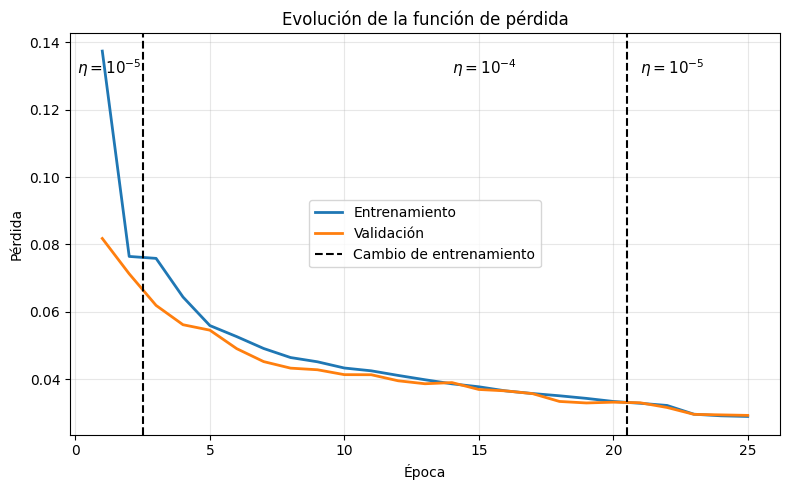

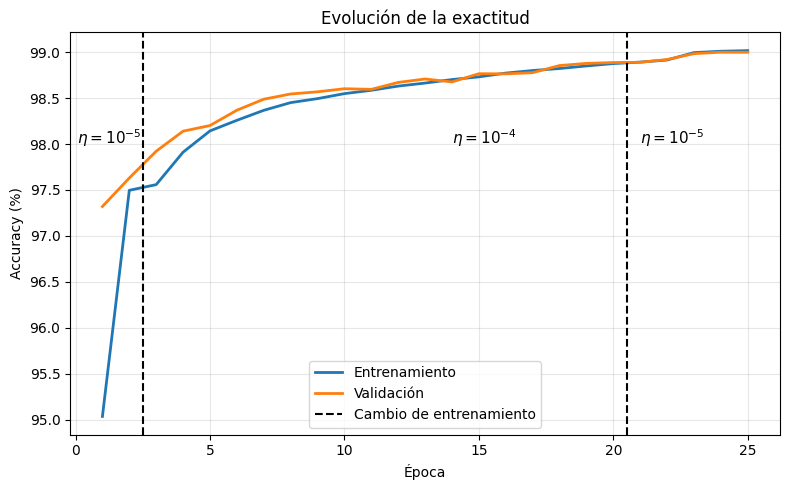

In [24]:
hist = np.array(historial)

loss_train = hist[:,1]
acc_train  = hist[:,2]
loss_val   = hist[:,3]
acc_val    = hist[:,4]

# Numeración continua de épocas
epocas = np.arange(1, len(hist)+1)

# Cambio de entrenamiento
cambio_1 = 2
cambio_2 = 20

# LOSS
plt.figure(figsize=(8,5))

plt.plot(epocas, loss_train,lw=2,label="Entrenamiento")

plt.plot(epocas, loss_val,lw=2,label="Validación")

plt.axvline(cambio_2+0.5,color="black",linestyle="--",label="Cambio de entrenamiento")
plt.axvline(cambio_1+0.5,color="black",linestyle="--")
plt.text(cambio_1-1.95,max(loss_train)*0.95,r"$\eta=10^{-5}$",fontsize=11)
plt.text(cambio_2-6,max(loss_train)*0.95,r"$\eta=10^{-4}$",fontsize=11)

plt.text(cambio_2+1,max(loss_train)*0.95,r"$\eta=10^{-5}$",fontsize=11)

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Evolución de la función de pérdida")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("loss_training.png",dpi=500)
plt.show()



# ACCURACY
plt.figure(figsize=(8,5))

plt.plot(epocas,acc_train*100,lw=2,label="Entrenamiento")

plt.plot(epocas,acc_val*100,lw=2,label="Validación")

plt.axvline(cambio_2+0.5,color="black",linestyle="--",label="Cambio de entrenamiento")
plt.axvline(cambio_1+0.5,color="black",linestyle="--")
plt.text(cambio_1-1.95,98,r"$\eta=10^{-5}$",fontsize=11)
plt.text(cambio_2-6,98,r"$\eta=10^{-4}$",fontsize=11)
plt.text(cambio_2+1,98,r"$\eta=10^{-5}$",fontsize=11)

plt.xlabel("Época")
plt.ylabel("Accuracy (%)")
plt.title("Evolución de la exactitud")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("accuracy_training.png",dpi=500)
plt.show()

# Hisotgrama de clasificación

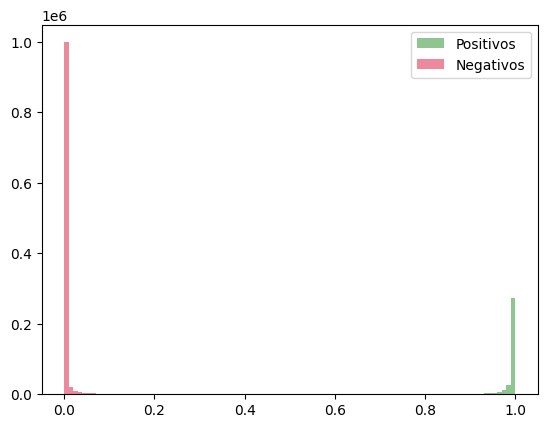

In [12]:
modelo.eval()

with torch.no_grad():
    pred = modelo(X_val.to(device)).cpu().numpy().ravel()
y_real = y_val.cpu().numpy().ravel()

plt.hist(pred[y_real == 1],bins=100,alpha=0.5,label="Positivos", color = "forestgreen")
plt.hist(pred[y_real == 0],bins=100,alpha=0.5,label="Negativos", color = "crimson")

plt.legend()

plt.savefig("/kaggle/working/histograma.png",dpi=300,bbox_inches="tight")
plt.show()

Matriz de confusión:
[[1066428    7022]
 [   7314  350785]]


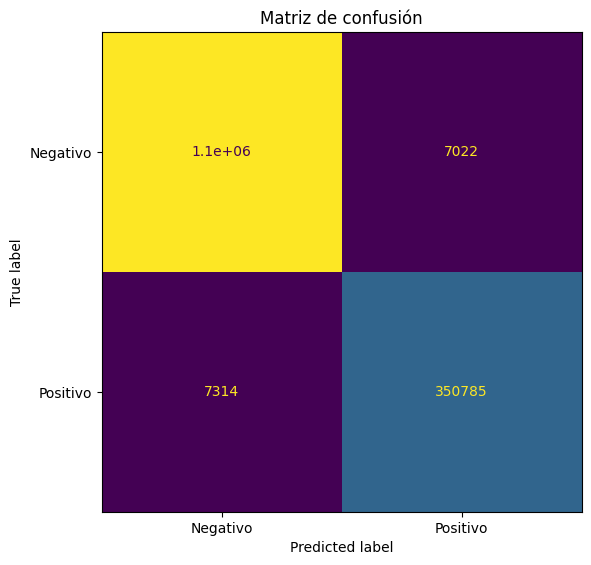

TP = 350785
TN = 1066428
FP = 7022
FN = 7314

Accuracy  = 99.00%
Precision = 98.04%
Recall    = 97.96%


/tmp/ipykernel_78053/1075622541.py:94: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_78053/1075622541.py:95: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("curva_ROC.png", dpi=600, bbox_inches="tight")
/tmp/ipykernel_78053/1075622541.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("curva_ROC.pdf", bbox_inches="tight")
/tmp/ipykernel_78053/1075622541.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("curva_ROC.pdf", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


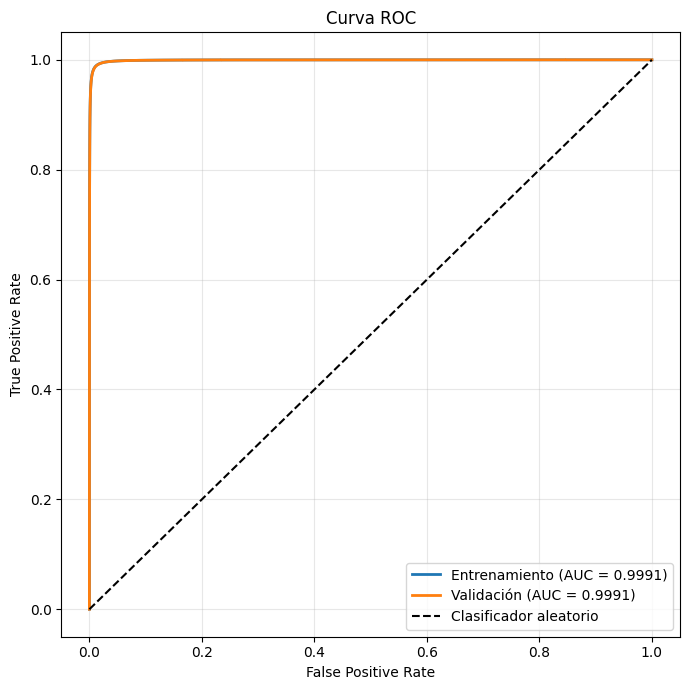

AUC entrenamiento: 0.9991
AUC validación:    0.9991


In [29]:
# MATRIZ DE CONFUSIÓN
y_pred = (pred > 0.5).astype(int)

cm = confusion_matrix(y_real, y_pred)
print("Matriz de confusión:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativo", "Positivo"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de confusión")

plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=600, bbox_inches="tight")
plt.savefig("matriz_confusion.pdf", bbox_inches="tight")

plt.show()

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")

accuracy = (TP+TN)/(TP+TN+FP+FN)
precision = TP/(TP+FP)
recall = TP/(TP+FN)

print(f"\nAccuracy  = {accuracy*100:.2f}%")
print(f"Precision = {precision*100:.2f}%")
print(f"Recall    = {recall*100:.2f}%")


# Para obtener la curva ROC necesitamos las predicciones del modelo
modelo.eval()

# Con esta función se realizarán predicciones por batches para obtener la curva ROC

def predecir(modelo, X, batch_size=50000):
    pred = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = X[i:i+batch_size].to(device)
            salida = modelo(batch)
            pred.append(salida.cpu().numpy())
    return np.concatenate(pred).ravel()

prob_train = predecir(modelo, X_train)
prob_val   = predecir(modelo, X_val)

y_train_np = y_train.cpu().numpy().ravel()
y_val_np   = y_val.cpu().numpy().ravel()

fpr_train, tpr_train, _ = roc_curve(y_train_np, prob_train)
fpr_val, tpr_val, _ = roc_curve(y_val_np, prob_val)

auc_train = auc(fpr_train, tpr_train)
auc_val = auc(fpr_val, tpr_val)

plt.figure(figsize=(7,7))

plt.plot(fpr_train,tpr_train,linewidth=2,label=f"Entrenamiento (AUC = {auc_train:.4f})")

plt.plot(fpr_val, tpr_val, linewidth=2, label=f"Validación (AUC = {auc_val:.4f})")

plt.plot([0,1],[0,1],'k--',label="Clasificador aleatorio")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("curva_ROC.png", dpi=600, bbox_inches="tight")
plt.savefig("curva_ROC.pdf", bbox_inches="tight")

plt.show()

print(f"AUC entrenamiento: {auc_train:.4f}")
print(f"AUC validación:    {auc_val:.4f}")

In [14]:
modelo.load_state_dict(torch.load("/kaggle/input/datasets/manuelsnchezrodrguez/con-dbscan/modelo_inicial.pt"))

<All keys matched successfully>

# Entrenamiento con negativos difíciles

In [ ]:
Train_hard = []
modelo.eval()

# Lo hacemos para 15 eventos
for event_id in range(10,25):
    # print(f"Evento {event_id}")
    evento = f'event0000010{event_id:02d}'
    zipi = zipfile.ZipFile(ruta_train1,'r')
    hits = pd.read_csv(zipi.open(f'train_1/{evento}-hits.csv'))
    cells = pd.read_csv(zipi.open(f'train_1/{evento}-cells.csv'))
    truth = pd.read_csv(zipi.open(f'train_1/{evento}-truth.csv'))
    zipi.close()

    features, grupos = features_hits(hits,cells,detectors)
    
    # PARES NEGATIVOS ALEATORIOS. Proceso similar al del primer entrenamiento.
    size=len(entreno1)*3
    n_hits = len(hits)
    i = np.random.randint(0,n_hits,size)
    j = np.random.randint(0,n_hits,size)
    p = truth.particle_id.values
    mask = ((p[i] == 0)|(p[i] != p[j]))
    pares_negativos = np.column_stack([i[mask],j[mask]])
    same_cluster = (grupos[pares_negativos[:,0]] ==grupos[pares_negativos[:,1]]).astype(np.float32)
    Train0 = np.column_stack([features[pares_negativos[:,0]], features[pares_negativos[:,1]], same_cluster, np.zeros(len(pares_negativos))])
    
    # Predicciones por batches
    predicciones = []
    batch_size = 30000
    with torch.no_grad():
        for inicio in range(0,len(Train0),batch_size):
            fin = min(inicio + batch_size,len(Train0))
            # Creamos el tensor en la CPU de forma normal
            batch = torch.tensor(Train0[inicio:fin, :-1], dtype=torch.float32)
            pred_batch = modelo(batch)   # Introducimos el batch en el modelo
            predicciones.append(pred_batch.cpu().numpy())  # AÑadimos esas predicciones
            del batch
            del pred_batch
    pred = np.concatenate(predicciones).ravel()

    # Los negativos difíciles serán aquellos que se encientren en un rango entre 0.5 y 0.95 de probabilidad.
    idx_hard = np.where((pred > 0.5) & (pred < 0.95))[0]
    Train_hard.append(Train0[idx_hard])

Train_hard = np.vstack(Train_hard)
print("Entreno original:", len(entreno))
print("Negativos difíciles:", len(Train_hard))
print(f"Fracción: {len(Train_hard)/len(entreno)*100:.2f}%")
print("Negativos difíciles:",Train_hard.shape)

# Los unimos, añadiendo varias veces los train_hard
entreno_hard_arr = np.vstack([entreno, Train_hard, Train_hard, Train_hard])
np.random.shuffle(entreno_hard_arr)

X_hard = torch.tensor(entreno_hard_arr[:,:-1], dtype=torch.float32)
y_hard = torch.tensor(entreno_hard_arr[:,-1], dtype=torch.float32).reshape(-1,1)


In [17]:
# Entrenamiento con negativos difíciles
entrenar(lr=1e-4,epocas=30,model=modelo, X=X_hard, Y=y_hard, loss=perdida)
entrenar(lr=1e-5,epocas=10, model=modelo, X=X_hard, Y=y_hard, loss=perdida)
entrenar(lr=1e-6,epocas=2, model=modelo, X=X_hard, Y=y_hard, loss=perdida)

with torch.no_grad():
    pred = modelo(X_val).cpu().numpy().ravel()  # modelo_hard, no modelo
y_real = y_val.cpu().numpy().ravel()


LR=1e-04 | Epoch 1/30 | Loss=0.051790 | Acc=0.9791 | ValLoss=0.038437 | ValAcc=0.9858 | Time=42.97 s|
LR=1e-04 | Epoch 2/30 | Loss=0.050144 | Acc=0.9800 | ValLoss=0.035976 | ValAcc=0.9867 | Time=41.16 s|
LR=1e-04 | Epoch 3/30 | Loss=0.048860 | Acc=0.9806 | ValLoss=0.039270 | ValAcc=0.9850 | Time=42.17 s|
LR=1e-04 | Epoch 4/30 | Loss=0.047864 | Acc=0.9810 | ValLoss=0.036417 | ValAcc=0.9861 | Time=41.87 s|
LR=1e-04 | Epoch 5/30 | Loss=0.046910 | Acc=0.9815 | ValLoss=0.037040 | ValAcc=0.9858 | Time=41.98 s|
LR=1e-04 | Epoch 6/30 | Loss=0.046396 | Acc=0.9817 | ValLoss=0.034219 | ValAcc=0.9871 | Time=41.71 s|
LR=1e-04 | Epoch 7/30 | Loss=0.045335 | Acc=0.9821 | ValLoss=0.033982 | ValAcc=0.9871 | Time=41.51 s|
LR=1e-04 | Epoch 8/30 | Loss=0.044685 | Acc=0.9823 | ValLoss=0.037078 | ValAcc=0.9854 | Time=41.51 s|
LR=1e-04 | Epoch 9/30 | Loss=0.044011 | Acc=0.9826 | ValLoss=0.032059 | ValAcc=0.9880 | Time=41.44 s|
LR=1e-04 | Epoch 10/30 | Loss=0.043629 | Acc=0.9828 | ValLoss=0.034273 | ValAcc=0.

In [ ]:
np.save("hard_negatives.npy", Train_hard)
torch.save(modelo.module.state_dict(), "/kaggle/working/modelo_ha.pt")
torch.save(X_hard, "/kaggle/working/X_hard.pt")
torch.save(y_hard, "/kaggle/working/y_hard.pt")

In [ ]:
modelo.load_state_dict(torch.load("/kaggle/input/datasets/manuelsnchezrodrguez/con-dbscan/modelo_hard.pt"))

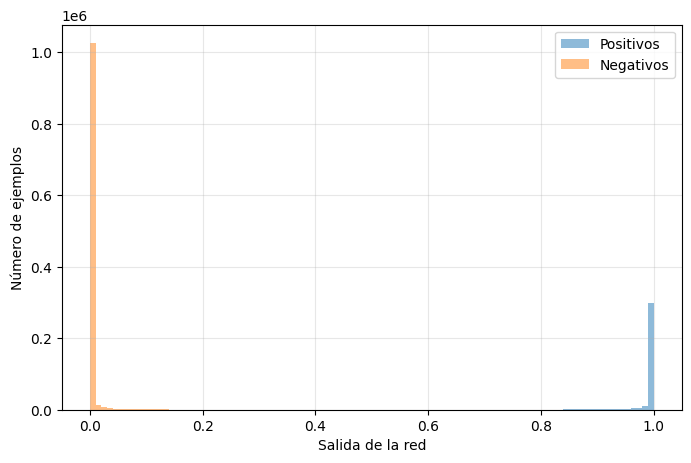


Matriz de confusión:
[[1071355    2159]
 [  11665  346370]]

Classification report:

              precision    recall  f1-score   support

         0.0     0.9892    0.9980    0.9936   1073514
         1.0     0.9938    0.9674    0.9804    358035

    accuracy                         0.9903   1431549
   macro avg     0.9915    0.9827    0.9870   1431549
weighted avg     0.9904    0.9903    0.9903   1431549



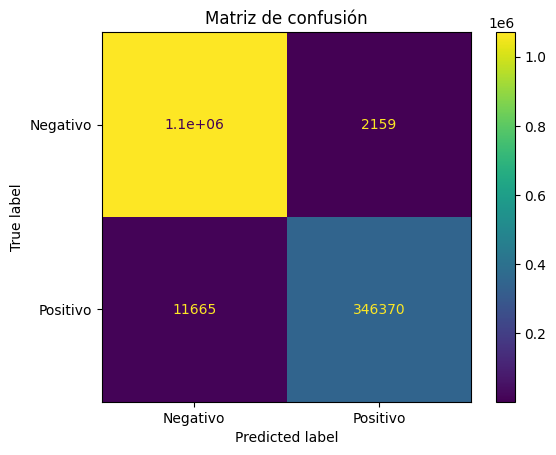

TP = 346370
TN = 1071355
FP = 2159
FN = 11665

Accuracy  = 99.03%
Precision = 99.38%
Recall    = 96.74%


In [ ]:
# HISTOGRAMA DE PREDICCIONES

plt.figure(figsize=(8,5))

plt.hist(pred[y_real == 1],bins=100,alpha=0.5,label="Positivos", color = "forestgreen")
plt.hist(pred[y_real == 0],bins=100,alpha=0.5,label="Negativos", color = "crimson")

plt.xlabel("Salida de la red")
plt.ylabel("Número de ejemplos")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/histograma_hard.png",dpi=300,bbox_inches="tight")
plt.show()

# MATRIZ DE CONFUSIÓN

y_pred = (pred > 0.5).astype(int)

cm = confusion_matrix(y_real,y_pred)

print("\nMatriz de confusión:")
print(cm)

print("\nClassification report:\n")

print(classification_report(y_real,y_pred,digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo","Positivo"])
disp.plot()
plt.title("Matriz de confusión")
plt.show()

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f"\nAccuracy  = {accuracy*100:.2f}%")
print(f"Precision = {precision*100:.2f}%")
print(f"Recall    = {recall*100:.2f}%")

# Para obtener la curva ROC necesitamos las predicciones del modelo
modelo.eval()
def predecir(modelo, X, batch_size=50000):
    pred = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = X[i:i+batch_size].to(device)
            salida = modelo(batch)
            pred.append(salida.cpu().numpy())
    return np.concatenate(pred).ravel()
prob_train = predecir(modelo, X_hard)
prob_val   = predecir(modelo, X_val)

y_train_np = y_hard.cpu().numpy().ravel()
y_val_np   = y_val.cpu().numpy().ravel()

fpr_train, tpr_train, _ = roc_curve(y_train_np, prob_train)
fpr_val, tpr_val, _ = roc_curve(y_val_np, prob_val)

auc_train = auc(fpr_train, tpr_train)
auc_val = auc(fpr_val, tpr_val)

plt.figure(figsize=(7,7))

plt.plot(fpr_train,tpr_train,linewidth=2,label=f"Entrenamiento (AUC = {auc_train:.4f})")

plt.plot(fpr_val,tpr_val,linewidth=2,label=f"Validación (AUC = {auc_val:.4f})")

plt.plot([0,1],[0,1],'k--',label="Clasificador aleatorio")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("curva_ROC.png", dpi=600, bbox_inches="tight")
plt.savefig("curva_ROC.pdf", bbox_inches="tight")

plt.show()

print(f"AUC entrenamiento: {auc_train:.4f}")
print(f"AUC validación:    {auc_val:.4f}")


In [17]:
modelo.load_state_dict(torch.load("/kaggle/input/datasets/manuelsnchezrodrguez/con-dbscan/modelo_hard.pt"))

<All keys matched successfully>

# Evaluamos el evento 1001

In [28]:
# Obtendremos las trayectorias para el elveno 1001
evento = 'event000001001'
zipi = zipfile.ZipFile(ruta_train1,'r')
hits = pd.read_csv(zipi.open(f'train_1/{evento}-hits.csv'))
cells = pd.read_csv(zipi.open(f'train_1/{evento}-cells.csv'))
truth = pd.read_csv(zipi.open(f'train_1/{evento}-truth.csv'))
zipi.close()

features, grupos = features_hits(hits, cells, detectors) # Variables
# np.save("features_event001.npy", features)

# Contamos los impactos registrados en cada módulo del detector
count = hits.groupby(['volume_id','layer_id','module_id'])['hit_id'].count().values 

# Obtenemos en qué modulo del detector cae cada impacto
module_id = np.zeros(len(hits),dtype=np.int32)
for i in range(len(count)):
    si = np.sum(count[:i])
    module_id[si:si+count[i]] = i
    
den = 37 # neuronas en la capa de entrada
en = 18 # número de features



# Con esta función se calcula, para un hit, la probabilidad de que el resto pertenezcan a al trayectoria
def get_predict(hit, thr=0.5):
    Tx = np.zeros((len(features), den), dtype=np.float32) # Matriz de entrada
    Tx[:, :en] = np.tile(features[hit], (len(features), 1)) # Añadimos las features del hit
    Tx[:, en:2*en] = features # La segunda parte son el resto de features del resto de hits
    Tx[:, 2*en] = (grupos[hit] == grupos).astype(np.float32) # Variable que nos dice que impactos pertenecen al mismo grupo generado con DBSCAN

    # Para cada batch devolvemos la predicción asociada
    with torch.no_grad():
        pred = []
        batch_size = 20000
        for i in range(0,len(Tx),batch_size):
            batch = torch.tensor(Tx[i:i+batch_size],dtype=torch.float32).to(device)
            pred.append(modelo(batch).cpu().numpy())

        pred = np.concatenate(pred).ravel()
    # Realizamos un modelo de inferencia para las probabilidades llamado Test Time Argumentation TTA
    # Los índices para los cuales la probabilidad supere el umbral establecido realizaremos un intercambio
    idx = np.where(pred > thr)[0] 
    if len(idx) > 0:
        Tx2 = np.zeros((len(idx),den),dtype=np.float32)
        # Intercambiamos los dos hits
        Tx2[:, :en] = Tx[idx, en:2*en]
        Tx2[:, en:2*en] = Tx[idx, :en]
        
        # same_cluster permanece igual
        Tx2[:, 2*en] = Tx[idx, 2*en]

        # Obtenemos las predicciones para los datos ahora intercambiados
        with torch.no_grad():
            pred1 = []
            for i in range(0,len(Tx2),batch_size):
                batch = torch.tensor(Tx2[i:i+batch_size],dtype=torch.float32).to(device)
                pred1.append(modelo(batch).cpu().numpy())
            pred1 = np.concatenate(pred1).ravel()
            
        # La probabilidad final sera la media entre las dos
        pred[idx] = (pred[idx]+ pred1) / 2

    return pred

# FUNCIÓN PARA FORMAR LA TRAYECTORIA
def get_path(hit, mask, thr):
    path = [hit] # Inicio de la trayectoria, solo un hit
    a = 0
    
    while True:
        c = get_predict(path[-1],thr/2) # Calculamos las probabilidades con respecto al ultimo camino añadido
        mask = (c > thr) * mask # Eliminamos los candidatos que no cumplen el umbral
        mask[path[-1]] = 0 # Tambien se elimina ese impacto

        # Ahora donde la probabilidad SÍ supere el umbral
        cand = np.where(c > thr)[0]
        if len(cand) > 0:
            # Impedimos que una misma trayectoria contenga dos impactos registrados en el mismo módulo
            # (una partícula no puede producir dos impactos a la vez)
            mask[cand[np.isin(module_id[cand],module_id[path])]] = 0
        
        a = (c + a) * mask # Acumulamos la probabilidad
        
        # Si ningun candidato supera el criterio salimos del bucle
        if a.max() < thr*len(path):
            break
        # Sino añadimos el candidato al camino
        path.append(int(a.argmax()))

    return sorted(path)

# Devuelvo los 10 primeros hits
for hit in range(10):
    path = get_path(hit,np.ones(len(truth)),0.9)
    gt = np.where(truth.particle_id.values==truth.particle_id.iloc[hit])[0]

    print()
    print("hit_id =", hit+1)
    print("reconstruct :", path)
    print("ground truth:", gt.tolist())



hit_id = 1
reconstruct : [0, 1228, 1259, 2656, 2720, 4427, 4477, 6494, 6568, 6624, 8927, 9006, 9024, 11361]
ground truth: [0, 1236, 1259, 2656, 2711, 4429, 4501, 6492, 6568, 6624, 8927, 9006, 9024, 11361]

hit_id = 2
reconstruct : [1, 1270, 1314, 2703, 2763, 4478, 4546, 6482, 6527, 6607, 8917, 9003, 9038, 11366]
ground truth: [1, 1270, 1314, 2703, 2763, 4478, 4546, 6482, 6527, 6607, 8917, 9003, 9038, 11366]

hit_id = 3
reconstruct : [2, 1258, 2709, 2756, 4428, 4480, 4529, 6480, 6541, 6608, 8925]
ground truth: [2, 1258, 2709, 2756, 4428, 4480, 4529, 6480, 6541, 6608, 8925]

hit_id = 4
reconstruct : [3, 40, 1265, 1299, 2716, 2761, 4490, 4548, 6554, 6600, 8939, 8997, 9058, 11365]
ground truth: [3, 40, 1265, 1299, 2716, 2761, 4490, 4548, 6554, 6600, 8939, 8997, 9058, 11365]

hit_id = 5
reconstruct : [4, 1239, 1275, 2658, 2708, 4447, 4473, 6505, 6539, 8947, 9009, 11354, 11415, 11486, 13816, 13869]
ground truth: [4, 1239, 1275, 2658, 2708, 4447, 4473, 6505, 6539, 8947, 9009, 11354, 11415, 1

# Comienza la reconstrucción 

In [29]:
'''
Tomo un valor fijo de hits que voy a usar. Solo trabajaré con los primeros 50000 hits de los 93680 que hay.
Esto es por un tema de tiempo, ya que para obtener un resultado sobre los 93680 hits puede durar varias horas
Usando los 50000 primeros solo tarda una hora (que ya es bastante)
'''
N = 20000

hits = hits.iloc[:N].reset_index(drop=True)

truth = truth.iloc[:N].reset_index(drop=True)

hit_ids_validos = hits.hit_id.values

cells = cells[cells.hit_id.isin(hit_ids_validos)].reset_index(drop=True)

print("Hits :", len(hits))
print("Truth:", len(truth))
print("Cells:", len(cells))

features, grupos = features_hits(hits,cells, detectors) # Calculo las variables 

preds = [] # Creo una lista vacía con las predicciones que añadiremos

# Crearemos dos matrices vacías en las que añadiremos la información de los hits
TestX1 = np.zeros((len(features), den), dtype=np.float32)
TestX1[:, :en] = features # Guardamos en la primera mitad la información del primer impacto
TestX = np.zeros((len(features), den), dtype=np.float32)
TestX[:, en:2*en] = features # Guardamos en la segunda mitad la información del segundo 


batch_size = 4000 # Tamaño de lote empleado en la inferencia

# Recorremos todos los hits
for i in range(len(features)-1):
    if i % 1000 == 0:
        print(i,"/",len(features))
        
    # Cada hit sera el primer elemento del doblete
    TestX[i+1:,:en] = np.tile(features[i],(len(features)-i-1,1))
    
    # Se añade además la variable del DBSCAN
    TestX[i+1:, 2*en] = (grupos[i] == grupos[i+1:]).astype(np.float32)
    
    pred_total = []
    # Obtenemos las predicciones correspondientes. Desactivamos los gradientes porque no entrenamos
    with torch.no_grad():
        for k in range(0,len(TestX)-i-1,batch_size):
            batch = torch.tensor(TestX[i+1+k:min(i+1+k+batch_size,len(TestX))],dtype=torch.float32).to(device) # A la GPU
            pred_total.append(modelo(batch).cpu().numpy()) # Predicciones
    pred = np.concatenate(pred_total).ravel() # Unimos todas

    idx = np.where(pred > 0.5)[0] # Solo nos quedamos con aquellas con probabilidad mayor a 0.5

    # Proceso de TTA
    with torch.no_grad():
        Tx2 = np.zeros((len(idx), den), dtype=np.float32)
        
        # Intercambiamos los dos hits de posición
        Tx2[:, :en] = TestX[idx+i+1, en:2*en]
        Tx2[:, en:2*en] = TestX[idx+i+1, :en]
        # same_cluster permanece igual
        Tx2[:, 2*en] = TestX[idx+i+1, 2*en]
        Xtta = torch.tensor(Tx2, dtype=torch.float32).to(device)
        pred1 = modelo(Xtta).cpu().numpy().ravel()

    pred[idx] = (pred[idx]+pred1) / 2  # Se realiza una media entre las dos predicciones.
        
    idx = np.where(pred > 0.5)[0] # Solo nos quedamos con aquellas con una probabilidad de más del 0.5
    preds.append([idx+i+1,pred[idx]])
    
preds.append([np.array([],dtype=np.int64),np.array([],dtype=np.float32)])

# Ahora recorremos el bucle hacia atrás para ver que conexiones hay entre los hits. Para conectarlos
for i in range(len(preds)):
    ii = len(preds)-i-1 # Empezamos por el final
    
    # Recorremos los hits que esten conectados con el hit ii
    for j in range(len(preds[ii][0])):
        jj = preds[ii][0][j] 
        preds[jj][0] = np.insert(preds[jj][0],0,ii) # Aqui añadimos ese vecino a la conexión que había
        preds[jj][1] = np.insert(preds[jj][1],0,preds[ii][1][j]) # Aquí añadimos la probabilidad asociada a esa conexion

# Los guardamos
preds = np.array(preds,dtype=object)
print("preds construido")
np.save("preds_event001.npy", preds)

Hits : 40000
Truth: 40000
Cells: 341440
0 / 40000
1000 / 40000
2000 / 40000
3000 / 40000
4000 / 40000
5000 / 40000
6000 / 40000
7000 / 40000
8000 / 40000
9000 / 40000
10000 / 40000
11000 / 40000
12000 / 40000
13000 / 40000
14000 / 40000
15000 / 40000
16000 / 40000
17000 / 40000
18000 / 40000
19000 / 40000
20000 / 40000
21000 / 40000
22000 / 40000
23000 / 40000
24000 / 40000
25000 / 40000
26000 / 40000
27000 / 40000
28000 / 40000
29000 / 40000
30000 / 40000
31000 / 40000
32000 / 40000
33000 / 40000
34000 / 40000
35000 / 40000
36000 / 40000
37000 / 40000
38000 / 40000
39000 / 40000
preds construido


In [30]:
preds = []  # Lista vacía donde se guardarán las predicciones
TestX = np.zeros((len(features), den), dtype=np.float32) # Matriz vacía para añadir las entradas de la red
TestX[:, en:2*en] = features # En la segunda mitad se añaden las variables del segundo hit

batch_size = 50000 # Tamaño del batch

for i in range(len(features)-1):
    if i % 1000 == 0:
        print(i, "/", len(features))
        
    # Cada hit sera el primer elemento del doblete
    TestX[i+1:,:en] = np.tile(features[i],(len(TestX)-i-1,1))
    # Rellenamos los candidatos con los hits posteriores
    TestX[i+1:, en:2*en] = features[i+1:]
    
    # Variable del DBSCAN
    TestX[i+1:, 2*en] = (grupos[i] == grupos[i+1:]).astype(np.float32)

    # Predicciones, como antes
    pred_total = []
    with torch.no_grad():
        for k in range(0,len(TestX)-i-1,batch_size):
            batch = torch.tensor(TestX[i+1+k :min(i+1+k+batch_size,len(TestX))],dtype=torch.float32).to(device)
            pred_total.append(modelo(batch).cpu().numpy())
    pred = np.concatenate(pred_total).ravel()

    # Primero observamos cuales de ellos tienen una probabilidad superior al 0.2
    idx = np.where(pred > 0.2)[0]

    # Si los hay obtenemos probabilidades y sino, no.
    if len(idx) > 0:
        Tx2 = np.zeros((len(idx), den), dtype=np.float32)

        # Intercambiamos hit1 y hit2
        Tx2[:, :en] = TestX[idx+i+1, en:2*en]
        Tx2[:, en:2*en] = TestX[idx+i+1, :en]
        
        # same_cluster permanece igual
        Tx2[:, 2*en] = TestX[idx+i+1, 2*en]

        # Predicciones
        pred1_total = []
        with torch.no_grad():
            for k in range(0, len(idx), batch_size):
                batch = torch.tensor(Tx2[k:k+batch_size],dtype=torch.float32).to(device)
                pred1_total.append(modelo(batch).cpu().numpy())
        
        pred1 = np.concatenate(pred1_total).ravel()
        
    # Ahora comprobamos aquellas con probabilidad mayor a un 0.5
    idx = np.where(pred > 0.5)[0]
    preds.append([idx+i+1,pred[idx]])
preds.append([np.array([],dtype=np.int64),np.array([],dtype=np.float32)])

# Repetimos el proceso de conectar los hits recorriendo el vector de preds en sentido contrario
for i in range(len(preds)):
    ii = len(preds)-i-1
    for j in range(len(preds[ii][0])):
        jj = preds[ii][0][j]
        preds[jj][0] = np.insert(preds[jj][0],0,ii)
        preds[jj][1] = np.insert(preds[jj][1],0,preds[ii][1][j])

preds = np.array(preds,dtype=object)
print()
print("preds construido")

# La función de predicciones 2 nos devuelve un vector con las probabilidades asociadas a cada hit que se introduzca
def get_predict2(p):
    c = np.zeros(len(preds),dtype=np.float32)
    c[preds[p][0]] = preds[p][1]
    return c


def get_path2(hit, mask, thr):
    path = [hit] # Inicio de la trayectoria, solo un hit
    a = 0
    while True:
        c = get_predict2(path[-1]) # Probabilidades del ultimo hit añadido a la trayectoria
        mask = (c > thr) * mask # Solo los candidatos que superen el umbral pasan
        mask[path[-1]] = 0 # No se vulve a seleccionar ese hit
        cand = np.where(c > thr)[0] # Los candidatos serán aquellos que superen el umbral

        # ELiminamos los hits pertenecientes al mismo módulo
        if len(cand) > 0:
            mask[cand[np.isin(module_id[cand],module_id[path])]] = 0
        
        a = (c + a) * mask # Acumulamos las probabilidades
        # Si ningun candidato alcanza la puntuación mínima exigida se para
        if a.max() < thr * len(path):
            break
            
        path.append(int(a.argmax())) # se añaden al camino aquellos que tengan la mayor probabilidad
    return path


tracks_all = [] # Lista para almacenar las trayectorias

thr = 0.85 # Umbral
multi = True # Para activar el método multipaso

# Creamos un bucle con cada iteracion para un hit
# MULTIPASO
for hit in range(len(preds)):
    if hit % 1000 == 0:
        print(hit, "/", len(preds))

    m = np.ones(len(truth))
    path = get_path2(hit,m,thr) # Pasamos el hit por la función que reconstruye trayectorias

    # Sí la longitud del camino es mayor a 1 y el metodo multipaso esta activo se elimina el segundo hit para ver si hay otra mas larga
    if multi and len(path) > 1:
        m[path[1]] = 0
        path2 = get_path2(hit,m,thr)

        # Si la longitud del primero menor entonces los igualamos y volvemos a eliminar el segundo se repite el proceso
        # El camino más largo suele ser el mejor
        if len(path) < len(path2):
            path = path2
            m[path[1]] = 0
            path2 = get_path2(hit,m,thr) 
            # Probamos otro camino diferente. Si ahora el siguiente es más largo nos quedamos con ese
            if len(path) < len(path2):
                path = path2
                
        # Si la longitud del segundo camino es mayor a 1 eliminamos el segundo hit de la segunda trayectoria
        # Mantenemos el de la primera y volvemos a calcular. SI ahora obtenemos una mejor trayectoria nos quedamos con ese
        elif len(path2) > 1:
            m[path[1]] = 1
            m[path2[1]] = 0
            path2 = get_path2(hit,m,thr)
            if len(path) < len(path2):
                path = path2

    tracks_all.append(path) # Añadimos los caminos a la lista de trayectorias
print("tracks_all construido")
tracks = np.zeros(len(hits), dtype=np.int32)

for track_id, path in enumerate(tracks_all, start=1):
    for hit in path:
        tracks[hit] = track_id # Damos a cada hit en la trayectoria su propio identificador de trayectoria
tracks = np.array(tracks, dtype=np.int32)
np.save("tracks_event001.npy",np.array(tracks, dtype=object)) # Guardamos
submission = pd.DataFrame({"hit_id":truth.hit_id.values,"track_id":tracks.astype(int)})

score = score_event(truth,submission)
print("-------------------------------")
print(f"Score ={score*100:.2f}%")
# ----------------------------------------------------------
# ESTADÍSTICAS
# ----------------------------------------------------------

n_conexiones = sum(len(p[0]) for p in preds)

longitudes = np.array([len(p[0]) for p in preds])

print("Conexiones totales:",n_conexiones)
print("Media conexiones:",n_conexiones/len(preds))
print("Máximo conexiones:",longitudes.max())

# Guardamos la reconstrucción buena
tracks_mp = tracks.copy()
track_id = int(tracks_mp.max())

0 / 40000
1000 / 40000
2000 / 40000
3000 / 40000
4000 / 40000
5000 / 40000
6000 / 40000
7000 / 40000
8000 / 40000
9000 / 40000
10000 / 40000
11000 / 40000
12000 / 40000
13000 / 40000
14000 / 40000
15000 / 40000
16000 / 40000
17000 / 40000
18000 / 40000
19000 / 40000
20000 / 40000
21000 / 40000
22000 / 40000
23000 / 40000
24000 / 40000
25000 / 40000
26000 / 40000
27000 / 40000
28000 / 40000
29000 / 40000
30000 / 40000
31000 / 40000
32000 / 40000
33000 / 40000
34000 / 40000
35000 / 40000
36000 / 40000
37000 / 40000
38000 / 40000
39000 / 40000

preds construido
0 / 40000
1000 / 40000
2000 / 40000
3000 / 40000
4000 / 40000
5000 / 40000
6000 / 40000
7000 / 40000
8000 / 40000
9000 / 40000
10000 / 40000
11000 / 40000
12000 / 40000
13000 / 40000
14000 / 40000
15000 / 40000
16000 / 40000
17000 / 40000
18000 / 40000
19000 / 40000
20000 / 40000
21000 / 40000
22000 / 40000
23000 / 40000
24000 / 40000
25000 / 40000
26000 / 40000
27000 / 40000
28000 / 40000
29000 / 40000
30000 / 40000
31000 / 40000


In [31]:
# Con esta funcion se asigna una puntuación de calidad a cada trayectoria reconstruida 
# analizando la coherencia de las conexiones entre sus hits.
def get_track_score(tracks_all, n=4):
    scores = np.zeros(len(tracks_all),dtype=np.float32) # Creamos un array de ceros con la longitud del array de tracks
    # Recorremos cada trayectoria 
    for i, path in enumerate(tracks_all):
        count = len(path) # contamos cuantos hits hay
        # Solo toma en cuenta aquellos con más de un hit
        if count > 1:
            tp = 0 # inicializamos los true positives que contarán como trayectoria correcta
            fp = 0 # inicializamos los false positives que contarán como trayectoria incorrecta
            
            # para cada hit
            for p in path:
                tp += np.sum(np.isin(tracks_all[p],path,assume_unique=True)) # Cuantos de los hits pertenecen a la trayectoria
                fp += np.sum(np.isin(tracks_all[p],path,assume_unique=True,invert=True)) # Cuantos no pertenecen a la trayectoria
            scores[i] = (tp- fp*n- count) / count / (count-1) # Cálculo de la coherencia
        else:
            scores[i] = -np.inf
    return scores

# Devuelve información sobre esas trayectorias, la más destacable el score oficial
def evaluate_tracks(tracks, truth):
    submission = pd.DataFrame({'hit_id':truth.hit_id.values,'track_id':tracks.astype(int)})
    score = score_event(truth,submission)
    track_id = tracks.max()
    print("RESULTADOS")
    print(f"Score = {score*100:.2f}%")
    print(f"Tracks reconstruidas: {tracks.max()}")
    print(f"Hits asignados: {np.sum(tracks > 0)}")
    print(f"Hits sin asignar: {np.sum(tracks == 0)}")

# Función para extender trayectorias. Se intentan alargar.
# Es muy similar a get_path2 en su primera parte
def extend_path(path,mask,thr,last=False):
    a = 0
    
    for p in path[:-1]: # Recorremos todos los hits de la trayectoria salvo el ultimo
        c = get_predict2(p) # probabilidades
        
        if last == False:
            mask = (c > thr) * mask # Se eliminan los candidatos que no superen el umbral
        mask[p] = 0 # Se elimina ese hit de la trayectoria
        cand = np.where( c > thr)[0]
        if len(cand) > 0:
            mask[cand[np.isin(module_id[cand],module_id[path])]] = 0 # Se eliminan los del mismo módulo
        a = (c + a) * mask
    
    # Aquí se extiende
    while True:
        c = get_predict2(path[-1]) # solo estudiamos las conexiones del último hit
        
        if last == False:
            mask = (c > thr) * mask
        mask[path[-1]] = 0
        cand = np.where(c > thr)[0]
        
        if len(cand) > 0:
            mask[cand[np.isin(module_id[cand],module_id[path])]] = 0
        a = (c + a) * mask 
        
        # Si el candidato es malo nos salimos y sino se añade al camino
        if a.max() < thr * len(path):
            break  
        path.append(int(a.argmax()))
        
        if last:
            break
            
    return path
    

scores = get_track_score(tracks_all) # Se obtiene la 'calidad' de la trayectoria 

In [32]:
# MULTIPASO
tracks_mp = np.zeros(len(hits),dtype=np.int32) # array de ceros
track_id = 0 # inicializador de indice a cero
idx = np.argsort(scores)[::-1] # Se ordenan de menor a mayor calidad
# TRAYECTORIAS LARGAS
for hit in idx:
    path = np.array(tracks_all[hit]) # obtenemos el camino para cada hit
    path = path[np.where(tracks_mp[path] == 0)[0]] # eliminamos hits que ya estan en otras trayectorias

    # Nos quedamos solo con aquellos con más de 6 hits
    if len(path) > 6:
        track_id += 1
        tracks_mp[path] = track_id
print("TRAYECTORIAS LARGAS")
evaluate_tracks(tracks_mp, truth)


# Repetimos el proceso extendiendo las trayectorias mayores a 3 hits
for hit in idx:
    path = np.array(tracks_all[hit])
    path = path[np.where(tracks_mp[path] == 0)[0]]
    if len(path) > 3:
        path = extend_path(path.tolist(),1 * (tracks_mp == 0),0.6) # Añadimos aquellos hits que no pertenezcana ninguna 
        track_id += 1
        tracks_mp[path] = track_id

print("TRAYECTORIAS NUEVAS")
evaluate_tracks(tracks_mp, truth)


#TRAYECTORIAS CORTAS

# Ahora buscamos extender aquellas con 2 o más hits, solo se conservarán si presentan más de 2 hits
for hit in idx:
    path = np.array(tracks_all[hit])
    path = path[np.where(tracks_mp[path] == 0)[0]]

    if len(path) > 1:
        path = extend_path(path.tolist(),1 * (tracks_mp == 0),0.5)

    if len(path) > 2:
        track_id += 1
        tracks_mp[path] = track_id

print("TRAYECTORIAS CORTAS")
evaluate_tracks(tracks_mp, truth)

# Finalmente se recorren todas las trayectorias de la reconstrucción 
for tid in range(1,int(tracks_mp.max()) + 1):
    path = np.where(tracks_mp == tid)[0]  # Se recuperan todos los hits

    # Finalmente la ultima comprobación es intentar alargar aquellas cuyo numero de hits sea par
    if len(path) % 2 == 0:
        path = extend_path(path.tolist(),1 * (tracks_mp == 0),0.5,True)
        tracks_mp[path] = tid

print("FINAL")
evaluate_tracks(tracks_mp, truth)

TRAYECTORIAS LARGAS
RESULTADOS
Score = 27.08%
Tracks reconstruidas: 1634
Hits asignados: 15882
Hits sin asignar: 24118
TRAYECTORIAS NUEVAS
RESULTADOS
Score = 52.98%
Tracks reconstruidas: 4564
Hits asignados: 30958
Hits sin asignar: 9042
TRAYECTORIAS CORTAS
RESULTADOS
Score = 58.34%
Tracks reconstruidas: 6263
Hits asignados: 37291
Hits sin asignar: 2709
FINAL
RESULTADOS
Score = 58.66%
Tracks reconstruidas: 6263
Hits asignados: 38179
Hits sin asignar: 1821
